## Imports

In [52]:
from bs4 import BeautifulSoup
import networkx as nx
import matplotlib.pyplot as plt

import numpy as np

## Parse all Moonbirds transactions

https://opensea.io/collection/proof-moonbirds?tab=activity

## Params

In [22]:
cnt = 1
date_ = "april_22"
asset_name = "moonbirds"
id_key = asset_name + "_id"

In [23]:
all_transactions = []

## Read data
fn = "../../data/{}_{}_{}.html".format(asset_name, date_, cnt)

while True:
    try:
        with open(fn, "r") as fp:
            print("Parsing {} ...".format(fn))
            html = fp.read()
            soup = BeautifulSoup(html)
            lisitem_divs = soup.findAll('div', {'role': 'listitem'})
            for item in lisitem_divs:
                divs = item.findAll('div', {'display': 'flex'})
                data = {}
                data[id_key] = divs[1].text.strip()
                prices = divs[2].text.split(" ")
                try:
                    data["eth"] = prices[0]
                except IndexError:
                    data["eth"] = -1
                try:
                    data["usd"] = prices[1]
                except IndexError:
                    data["usd"] = -1
                data["cnt"] = divs[3].text
                data["sender"] = divs[4].text
                data["receiver"] = divs[5].text
                data["date"] = divs[6].text
                all_transactions.append(data)
        cnt += 1
        # proceed to next file
        fn = "../../data/{}_{}_{}.html".format(asset_name, date_, cnt)
    except FileNotFoundError:
        break


Parsing ../../data/moonbirds_april_22_1.html ...
Parsing ../../data/moonbirds_april_22_2.html ...
Parsing ../../data/moonbirds_april_22_3.html ...
Parsing ../../data/moonbirds_april_22_4.html ...
Parsing ../../data/moonbirds_april_22_5.html ...
Parsing ../../data/moonbirds_april_22_6.html ...
Parsing ../../data/moonbirds_april_22_7.html ...
Parsing ../../data/moonbirds_april_22_8.html ...
Parsing ../../data/moonbirds_april_22_9.html ...
Parsing ../../data/moonbirds_april_22_10.html ...
Parsing ../../data/moonbirds_april_22_11.html ...
Parsing ../../data/moonbirds_april_22_12.html ...
Parsing ../../data/moonbirds_april_22_13.html ...
Parsing ../../data/moonbirds_april_22_14.html ...
Parsing ../../data/moonbirds_april_22_15.html ...
Parsing ../../data/moonbirds_april_22_16.html ...
Parsing ../../data/moonbirds_april_22_17.html ...
Parsing ../../data/moonbirds_april_22_18.html ...
Parsing ../../data/moonbirds_april_22_19.html ...
Parsing ../../data/moonbirds_april_22_20.html ...
Parsing .

## Review data

In [24]:
print("No of {} transactions: {}".format(asset_name, len(all_transactions)))

No of moonbirds transactions: 1547


## Find hubs

In [30]:
freqs = {}

for trans in all_transactions:
    try:
        items = trans[id_key].split("#")
        id_ = items[1].strip()
    except IndexError:
        continue
    try:
        freqs[id_] += 1
    except KeyError:
        freqs[id_] = 1

In [31]:
sorted_nfts = {k: v for k, v in sorted(freqs.items(), key=lambda item: item[1], reverse=True)} 

## Find most transacted items

In [33]:
k = 10

hubs = []
cnt = 1

for id_ in sorted_nfts.keys():
    hubs.append(id_)
    if cnt >= k:
        break
    cnt += 1

In [34]:
hubs

['2983',
 '2439',
 '6589',
 '5646',
 '7583',
 '6870',
 '3957',
 '4149',
 '3870',
 '7974']

## Generate Graph

In [36]:
g = nx.Graph()

for trans in all_transactions:
    try:
        items = trans[id_key].split("#")
        id_ = items[1].strip()
    except IndexError:
        continue

    sendr, rcvr = trans["sender"], trans["receiver"]
    g.add_edge(sendr, rcvr)

## Draw graph

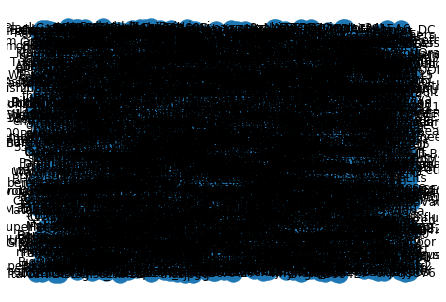

In [40]:
# clearing the current plot
plt.clf()
 
# drawing in random layout
nx.draw_random(g, with_labels = True)

# # drawing in circular layout
# nx.draw_circular(g, with_labels = True)

plt.savefig("../../figs/moonbirds_graph.png")

In [38]:
g.degree

DegreeView({'889365': 1, 'scvault': 1, '0xbbsx': 1, '4A2515': 1, 'Z-E-E': 1, 'AFFC71': 2, 'F8BE64': 2, '722CB1': 3, 'I_______I': 9, 'lowbrow': 1, '5058AF': 2, 'ravivora': 1, 'D17760': 3, 'YHP1': 3, '1D501C': 1, '2720A5': 2, 'RuggedPepeVault': 1, '2D1EAD': 2, 'djpauliep': 1, 'eth4nfts': 1, 'A79D25': 1, 'Snootchie': 1, 'DONUTT': 1, '242176': 1, 'Trub03': 1, '6AE90A': 1, '10776F': 1, 'FEFEAA': 1, 'uxt': 1, 'seeough': 1, 'Runner8518': 4, 'DigitalOrnithologist_...': 5, 'C5CC11': 2, '54296F': 1, 'FabriCrypto': 9, 'Don_DrAper': 3, 'woshinedie': 2, 'n-e-o': 1, 'lazyboy-vault': 1, 'GaiKakenOifenYam': 1, 'DC2D12': 1, 'silverfox.eth': 1, 'ddmetamask': 5, 'chillwillvault': 1, 'browsing888': 4, '0000000001111111': 1, 'kbf-vault': 1, 'ADecadeUnderTheInflue...': 2, 'JereCrypto': 3, '0ldtug': 2, 'moonpay-eth': 1, 'fluint': 1, 'pistachio1': 1, 'ZNZZ': 1, '8EC1CC': 1, 'MLO32': 2, 'BBE35A': 1, 'HummingbirdX': 1, 'Alupayida': 1, '651785': 1, 'GenDegen': 4, 'C6B651': 1, '_-MadamRosey-_': 3, '79D4D0': 1, 'C

In [39]:
sorted(g.degree, key=lambda x: x[1], reverse=True)[:10]

[('twincorporated', 11),
 ('9EC8E8', 10),
 ('llmj989', 10),
 ('I_______I', 9),
 ('FabriCrypto', 9),
 ('3EEDEA', 9),
 ('FNOPS', 8),
 ('SpielbergArtGalleryNe...', 7),
 ('我右拳打开了天化.eth', 7),
 ('Mr_Monkeyagi', 7)]

## Find Top k Most expensive transactions

In [45]:
prices = {}


for trans in all_transactions:
    try:
        id_ = trans[id_key].split("#")[1].strip()
        sender = trans["sender"]
        rcvr = trans["receiver"]
        price = trans["eth"]
        key = id_ + ";" + sender + ";" + rcvr + ";" + trans["date"]
        prices[key] = float(price)
    except KeyError:
        continue

In [46]:
len(prices)

1524

## Sort dict by value

In [49]:
sorted_items_by_price = sorted(prices.items(), key=lambda item: item[1], reverse=True)
sorted_items_by_price[:10]

[('6610;348EBF;C8C722;2 days ago open_in_new', 150.0),
 ('7205;713F27;TheArtchitech;5 days ago open_in_new', 130.0),
 ('5249;spookyonionz.eth;nmac;6 days ago open_in_new', 130.0),
 ('2018;6CB748;E947CF;5 days ago open_in_new', 118.0),
 ('6774;loxnocapers;TheLittleFish;2 days ago open_in_new', 90.0),
 ('4036;62F0DA;6E66D8;4 days ago open_in_new', 83.0),
 ('4190;66F63B;1FC7C4;2 days ago open_in_new', 80.0),
 ('2164;DB1;BlueMagicXYZ;5 days ago open_in_new', 79.69),
 ('666;214E3A;exar.eth;a day ago open_in_new', 76.66),
 ('2381;twincorporated;meepstorage;a day ago open_in_new', 75.0)]

In [50]:
sorted_items_by_price[-10:]

[('6669;zorvault;Danski79;6 days ago open_in_new', 12.68),
 ('2309;0FB19C;IllIIlIlIIlllI;6 days ago open_in_new', 12.679),
 ('7336;juanes;sky888;6 days ago open_in_new', 12.5),
 ('9945;lantonmills;Hamzouz_Begag;6 days ago open_in_new', 12.5),
 ('9944;lantonmills;nicejpegbro;6 days ago open_in_new', 12.5),
 ('4109;TankVS;ripxxx;6 days ago open_in_new', 12.5),
 ('2808;DFB8F8;EC0825;6 days ago open_in_new', 10.634),
 ('6105;FabriCrypto;565B52;5 days ago open_in_new', 9.5),
 ('2439;Vault-124;AndrewNFT-Vault;5 days ago open_in_new', 0.15),
 ('4190;Total_ETH;66F63B;3 days ago open_in_new', 0.02)]

## Moonbirds Price Distribution

In [53]:
price_vals = np.array(list(prices.values()))

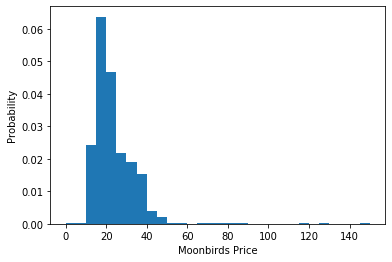

In [54]:
%matplotlib inline

plt.hist(price_vals, density=True, bins=30)  # density=False would make counts
plt.ylabel('Probability')
plt.xlabel('Moonbirds Price');